In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
df = pd.read_csv("../Data/student_placement_prediction_dataset_2026.csv")

In [3]:
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [4]:
df.sample(10)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
89543,89544,18,Male,7.98,ECE,Tier 2,0,1,0,77.469287,...,85.140774,89.375702,0,86.252548,76.034440,No,9.5,0.5,Placed,13.53
98679,98680,23,Female,7.37,CSE,Tier 2,0,4,4,58.841359,...,80.521561,77.190068,0,50.239361,74.126653,Yes,6.4,3.3,Placed,11.17
71627,71628,20,Female,7.61,CSE,Tier 3,1,3,2,76.340662,...,67.998101,94.216772,0,48.098259,65.734927,Yes,7.5,5.6,Not Placed,0.00
83600,83601,21,Male,7.74,Civil,Tier 3,1,3,1,90.005183,...,88.580702,97.157604,1,52.765936,79.264269,No,8.3,3.4,Placed,14.79
52412,52413,18,Male,7.85,CSE,Tier 2,2,3,1,83.706197,...,63.146420,100.000000,1,73.584038,49.580749,Yes,10.0,2.7,Not Placed,0.00
68386,68387,23,Female,7.15,Mechanical,Tier 3,1,4,2,59.371391,...,52.560223,100.000000,0,55.582202,27.181549,Yes,3.0,5.5,Placed,10.56
92291,92292,19,Female,7.51,CSE,Tier 3,4,4,3,77.102856,...,74.501451,87.984754,0,70.366775,74.318002,Yes,9.4,3.4,Placed,14.04
65271,65272,18,Female,7.67,CSE,Tier 2,0,3,2,62.259448,...,67.226305,68.727913,0,58.182302,42.824268,No,8.3,0.5,Placed,12.06
27894,27895,22,Male,8.73,EEE,Tier 2,0,5,2,54.851102,...,84.795607,83.293613,0,78.257466,59.635603,Yes,6.8,3.5,Placed,13.71
42829,42830,23,Male,7.02,EEE,Tier 2,2,2,1,95.982083,...,73.893303,72.466980,0,44.153234,30.355547,No,6.7,2.6,Not Placed,0.00


In [5]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [7]:
df.describe()

,student_id,age,cgpa,internships_count,projects_count,certifications_count,coding_skill_score,aptitude_score,communication_skill_score,logical_reasoning_score,...,github_repos,linkedin_connections,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,sleep_hours,study_hours_per_day,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,21.005740,7.496890,1.50223,3.001860,2.005150,69.825326,64.988108,67.960744,65.931696,...,4.005160,524.559110,69.989411,84.730169,0.497590,59.894049,54.937526,6.983319,3.523124,7.252106
std,28867.657797,1.999562,0.992834,1.22528,1.731764,1.416553,14.694618,14.844093,13.846636,14.826790,...,2.004897,274.993479,11.937257,9.416075,0.708434,19.549666,19.781197,1.468113,1.471248,6.735132
min,1.000000,18.000000,4.500000,0.00000,0.000000,0.000000,20.000000,20.000000,20.000000,20.000000,...,0.000000,50.000000,20.000000,50.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000
25%,25000.750000,19.000000,6.820000,1.00000,2.000000,1.000000,59.807945,54.894600,58.587535,55.940547,...,3.000000,287.000000,61.973172,78.325833,0.000000,46.538590,41.432390,6.000000,2.500000,0.000000
50%,50000.500000,21.000000,7.500000,1.00000,3.000000,2.000000,70.006250,65.011394,67.973221,66.003829,...,4.000000,523.000000,70.026665,85.018828,0.000000,60.079021,55.076210,7.000000,3.500000,11.100000
75%,75000.250000,23.000000,8.180000,2.00000,4.000000,3.000000,80.058762,75.079266,77.503749,76.113705,...,5.000000,764.000000,78.122083,91.782511,1.000000,73.549567,68.530115,8.000000,4.500000,13.470000
max,100000.000000,24.000000,10.000000,8.00000,13.000000,11.000000,100.000000,100.000000,100.000000,100.000000,...,16.000000,999.000000,100.000000,100.000000,6.000000,100.000000,100.000000,10.000000,10.000000,20.440000


In [8]:
# Missing Values
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

In [9]:
# Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [10]:
df["placement_status"].value_counts()

#This tells us whether the dataset is balanced.

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64

In [11]:
df["salary_package_lpa"].describe()

count    100000.000000
mean          7.252106
std           6.735132
min           0.000000
25%           0.000000
50%          11.100000
75%          13.470000
max          20.440000
Name: salary_package_lpa, dtype: float64

In [12]:
# Checking Categorical Columns
df.select_dtypes(include="object").columns

# These columns will need encoding later.

Index(['gender', 'branch', 'college_tier', 'volunteer_experience',
       'placement_status'],
      dtype='object')

In [13]:
# Checking Numerical Columns
df.select_dtypes(exclude="object").columns

#These are the columns we can scale and analyze numerically.

Index(['student_id', 'age', 'cgpa', 'internships_count', 'projects_count',
       'certifications_count', 'coding_skill_score', 'aptitude_score',
       'communication_skill_score', 'logical_reasoning_score',
       'hackathons_participated', 'github_repos', 'linkedin_connections',
       'mock_interview_score', 'attendance_percentage', 'backlogs',
       'extracurricular_score', 'leadership_score', 'sleep_hours',
       'study_hours_per_day', 'salary_package_lpa'],
      dtype='object')

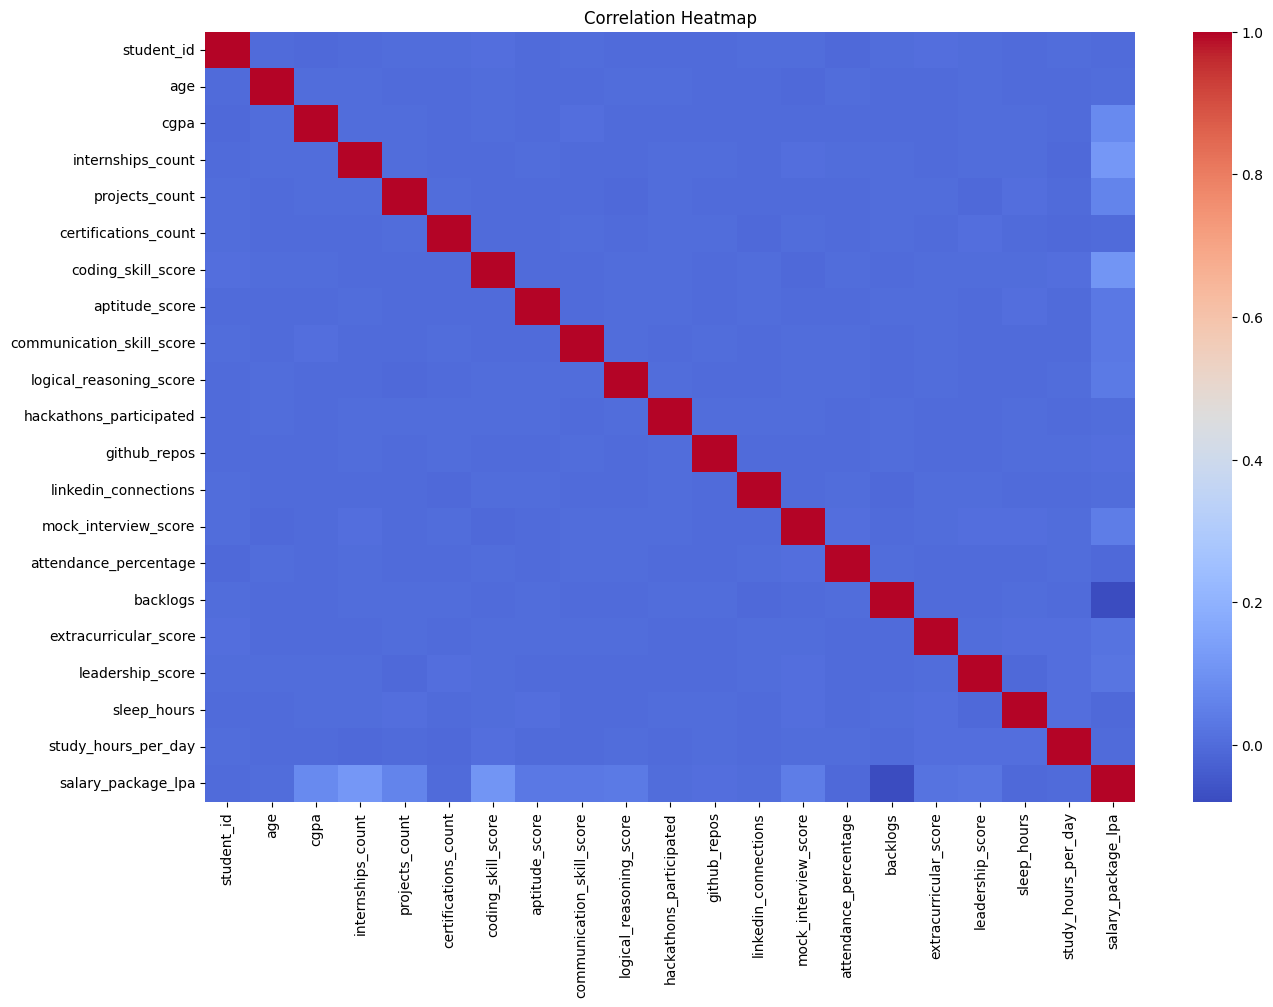

In [14]:
# checking how numerical features are related through heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

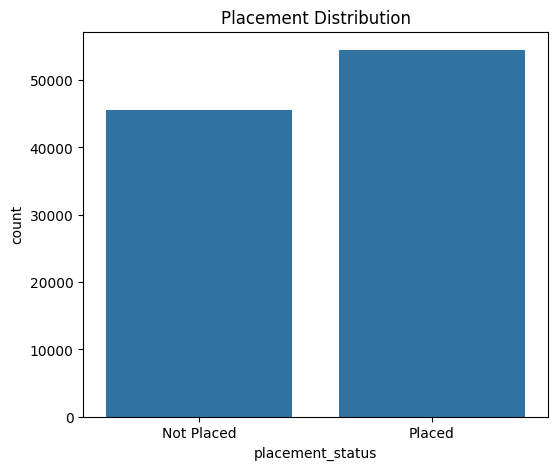

In [15]:
# placement distribution
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="placement_status")

plt.title("Placement Distribution")

plt.show()

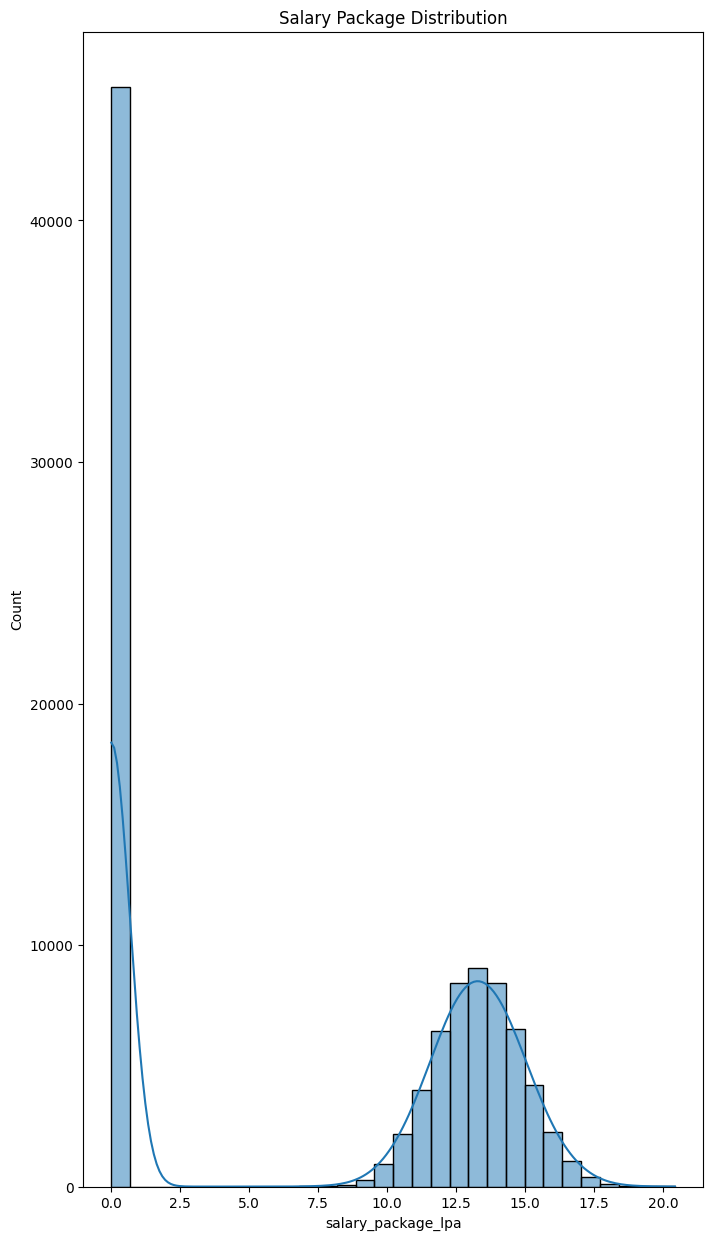

In [16]:
# Salary distribution
plt.figure(figsize=(8, 15))
sns.histplot(df["salary_package_lpa"], bins=30, kde=True)
plt.title("Salary Package Distribution")
plt.show()

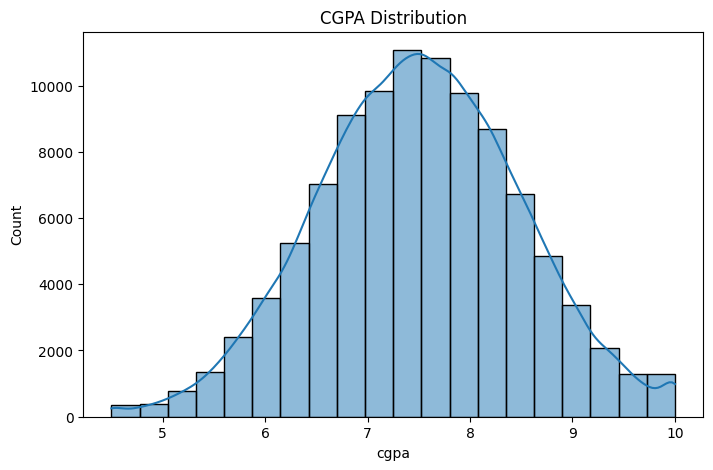

In [17]:
# CGPA distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["cgpa"], bins=20, kde=True)
plt.title("CGPA Distribution")
plt.show()

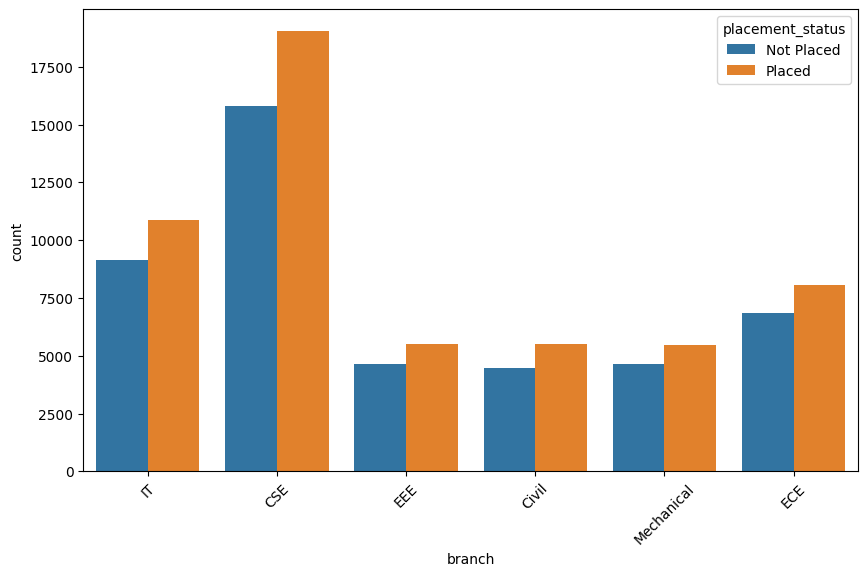

In [18]:
# Branch-wise Placement
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="branch", hue="placement_status")
plt.xticks(rotation=45)
plt.show()

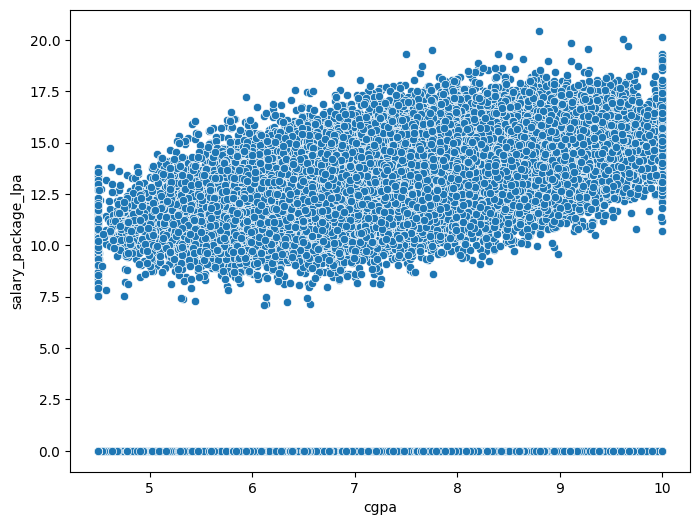

In [19]:
# Package vs CGPA
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="cgpa",
    y="salary_package_lpa"
)

plt.show()

In [21]:
df.columns

Index(['student_id', 'age', 'gender', 'cgpa', 'branch', 'college_tier',
       'internships_count', 'projects_count', 'certifications_count',
       'coding_skill_score', 'aptitude_score', 'communication_skill_score',
       'logical_reasoning_score', 'hackathons_participated', 'github_repos',
       'linkedin_connections', 'mock_interview_score', 'attendance_percentage',
       'backlogs', 'extracurricular_score', 'leadership_score',
       'volunteer_experience', 'sleep_hours', 'study_hours_per_day',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [22]:
# 1
df["placement_status"].value_counts()

# 2
df["placement_status"].value_counts(normalize=True)

# 3
df["placement_status"] = df["placement_status"].map({
    "Placed": 1,
    "Not Placed": 0
})

# 4
df.corr(numeric_only=True)["placement_status"].sort_values(ascending=False)

placement_status             1.000000
salary_package_lpa           0.984661
internships_count            0.063489
projects_count               0.060964
coding_skill_score           0.050773
mock_interview_score         0.046058
logical_reasoning_score      0.036332
communication_skill_score    0.032242
aptitude_score               0.031690
leadership_score             0.022170
extracurricular_score        0.020100
cgpa                         0.012067
github_repos                 0.004807
linkedin_connections         0.003223
hackathons_participated      0.001236
age                          0.000858
student_id                  -0.000821
study_hours_per_day         -0.001426
certifications_count        -0.003806
sleep_hours                 -0.004692
attendance_percentage       -0.008350
backlogs                    -0.082404
Name: placement_status, dtype: float64